In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for folder in os.listdir('./archive'):
    if 'IQ-OTHNCCD' in folder or 'lung' in folder.lower():
        dataset_path = os.path.join('./archive', folder)
        break


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
%config Completer.use_jedi = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import seaborn as sns
import cv2
import random
import os
import imageio
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from collections import Counter
import platform

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold
from imblearn.over_sampling import SMOTE

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from keras.applications import resnet

# CUDA / GPU setup (TensorFlow akan otomatis pakai GPU bila tersedia)
print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'CUDA GPU terdeteksi: {[gpu.name for gpu in gpus]}')
    except RuntimeError as e:
        print(f'Peringatan konfigurasi GPU: {e}')
else:
    print('GPU CUDA tidak terdeteksi. Training akan berjalan di CPU.')
    tf_major, tf_minor = map(int, tf.__version__.split('.')[:2])
    if platform.system() == 'Windows' and (tf_major > 2 or (tf_major == 2 and tf_minor >= 11)):
        print('Catatan: TensorFlow >= 2.11 di Windows native tidak mendukung CUDA GPU.')
        print('Solusi: pakai WSL2 + CUDA, atau gunakan TensorFlow 2.10 + CUDA 11.2 + cuDNN 8.1.')

TensorFlow version: 2.10.0
CUDA GPU terdeteksi: ['/physical_device:GPU:0']


In [3]:
directory = dataset_path

categories = ['Bengin cases', 'Malignant cases', 'Normal cases']

Bengin cases - Bengin case (1).jpg
Malignant cases - Malignant case (1).jpg
Normal cases - Normal case (1).jpg


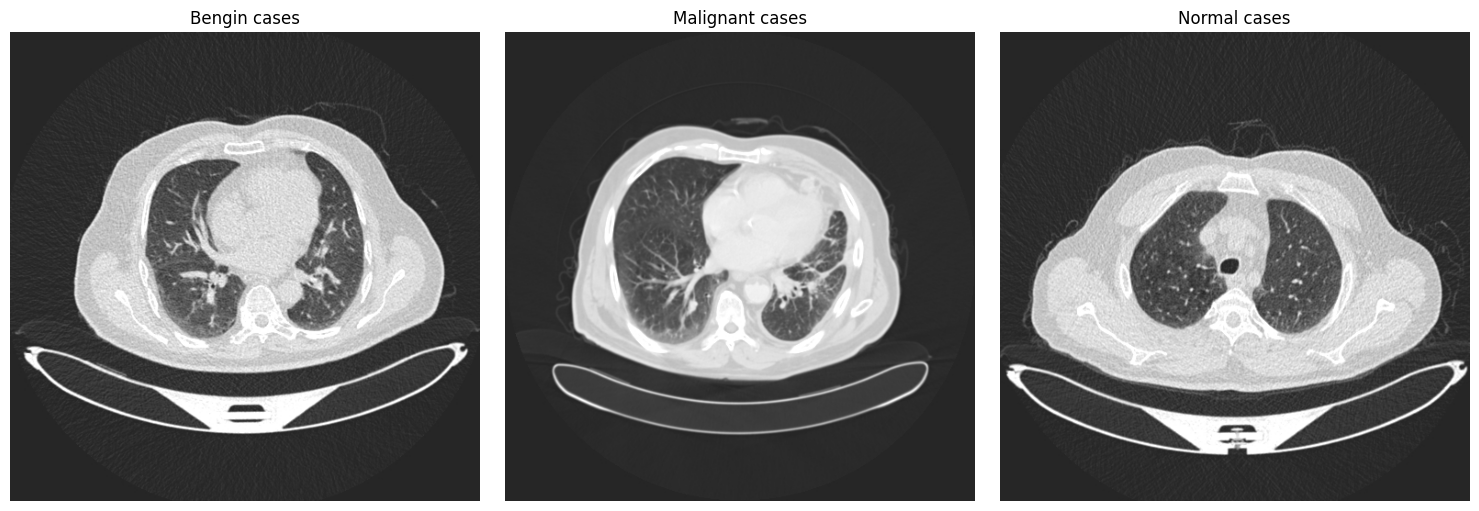

In [4]:
fig, axes = plt.subplots(1, len(categories), figsize=(15, 5))

for i, category in enumerate(categories):
    path = os.path.join(directory, category)
    # Loop files but break after the first one to show just one sample
    if not os.path.isdir(path):
        nested_path = os.path.join(directory, os.path.basename(directory), category)
        if os.path.isdir(nested_path):
            path = nested_path
        else:
            print(f"Folder tidak ditemukan: {path}")
            axes[i].axis('off')
            continue

    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        print(category, '-', file)

        # Baca image asli (BGR) dan konversi ke RGB
        img = cv2.imread(filepath)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Tampilkan di subplot yang sesuai
        axes[i].imshow(img)
        axes[i].set_title(f'{category}')
        axes[i].axis('off')
        break

plt.tight_layout()
plt.show()

In [5]:
size_data = {}
for i in categories:
    path = os.path.join(directory, i)
    class_num = categories.index(i)
    temp_dict = {}
    if not os.path.isdir(path):
        nested_path = os.path.join(directory, os.path.basename(directory), i)
        if os.path.isdir(nested_path):
            path = nested_path
        else:
            print(f"Folder tidak ditemukan: {path}")
            continue

    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        height, width, channels = imageio.imread(filepath).shape
        if str(height) + ' x ' + str(width) in temp_dict:
            temp_dict[str(height) + ' x ' + str(width)] += 1
        else:
            temp_dict[str(height) + ' x ' + str(width)] = 1

    size_data[i] = temp_dict

size_data

C:\Users\User\AppData\Local\Temp\ipykernel_24964\4177532465.py:16: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  height, width, channels = imageio.imread(filepath).shape


{'Bengin cases': {'512 x 512': 120},
 'Malignant cases': {'512 x 512': 501,
  '404 x 511': 1,
  '512 x 801': 28,
  '512 x 623': 31},
 'Normal cases': {'512 x 512': 415, '331 x 506': 1}}

In [6]:
import os, cv2, random
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Inisialisasi
data = []
img_size = 224 # WAJIB 224 untuk MobileNetV2

# Pastikan variabel 'categories' dan 'directory' sudah didefinisikan sebelumnya
for i in categories:
    path = os.path.join(directory, i)
    class_num = categories.index(i)

    if not os.path.isdir(path):
        nested_path = os.path.join(directory, os.path.basename(directory), i)
        if os.path.isdir(nested_path):
            path = nested_path
        else:
            print(f"Folder tidak ditemukan: {path}")
            continue

    for file in os.listdir(path):
        if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
            continue
        filepath = os.path.join(path, file)
        
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        # Konversi ke RGB karena MobileNetV2 mengharapkan 3 channel
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        data.append([img, class_num])

# Shuffle untuk memastikan variasi data saat splitting
random.shuffle(data)

# Memisahkan fitur (X) dan label (y)
X, y = zip(*data)
X = np.array(X, dtype=np.float32)
y = np.array(y)

print('--- Data Loaded ---')
print('Total X shape:', X.shape)
print('Label distribution:', Counter(y))

--- Data Loaded ---
Total X shape: (1097, 224, 224, 3)
Label distribution: Counter({1: 561, 2: 416, 0: 120})


In [7]:
# 1. SPLIT DATA → 70% TRAIN, 15% VALID, 15% TEST
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=10, 
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=10, 
    stratify=y_temp
)

# 2. PREPROCESS (Scaling pixel ke range yang sesuai MobileNetV2)
# X_train = preprocess_input(X_train)
# X_valid = preprocess_input(X_valid)
# X_test  = preprocess_input(X_test)

# 3. CLASS WEIGHT (Mencegah imbalance pada training)
counter = Counter(y_train)
total = len(y_train)
num_classes = len(categories)

class_weights = {i: total / (num_classes * counter[i]) for i in counter}

# 4. ONE HOT ENCODING
y_train = to_categorical(y_train, num_classes=num_classes)
y_valid = to_categorical(y_valid, num_classes=num_classes)
y_test  = to_categorical(y_test,  num_classes=num_classes)

print("--- Preprocessing Complete ---")
print("Class weights:", class_weights)
print("Train shape :", X_train.shape, y_train.shape)
print("Valid shape :", X_valid.shape, y_valid.shape)
print("Test  shape :", X_test.shape,  y_test.shape)

--- Preprocessing Complete ---
Class weights: {np.int64(2): 0.8785796105383734, np.int64(1): 0.6522108843537415, np.int64(0): 3.0436507936507935}
Train shape : (767, 224, 224, 3) (767, 3)
Valid shape : (165, 224, 224, 3) (165, 3)
Test  shape : (165, 224, 224, 3) (165, 3)


Building CNN + Attention Model


Model: "CNN_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_2             │ (None, 224, 224, 64)   │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_3             │ (None, 112, 112, 64)   │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 16)             │     3,211,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,252,243 (12.41 MB)

 Trainable params: 3,252,243 (12.41 MB)

 Non-trainable params: 0 (0.00 B)


Training Base Model
Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.4653 - loss: 62.7473 - val_accuracy: 0.8061 - val_loss: 0.4362
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8589 - loss: 0.4213 - val_accuracy: 0.9455 - val_loss: 0.1885
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9485 - loss: 0.1579 - val_accuracy: 0.9879 - val_loss: 0.0908
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9842 - loss: 0.0618 - val_accuracy: 0.9879 - val_loss: 0.0646
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.9899 - loss: 0.0521 - val_accuracy: 0.9818 - val_loss: 0.1015
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.9963 - loss: 0.0188 - val_accuracy: 0.9697 - val_loss: 0.0686
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.9948 - loss: 0.0097 - val_accuracy: 0.9879 - val_loss: 0.0404
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.9980 - loss: 0.0078 - val_accura

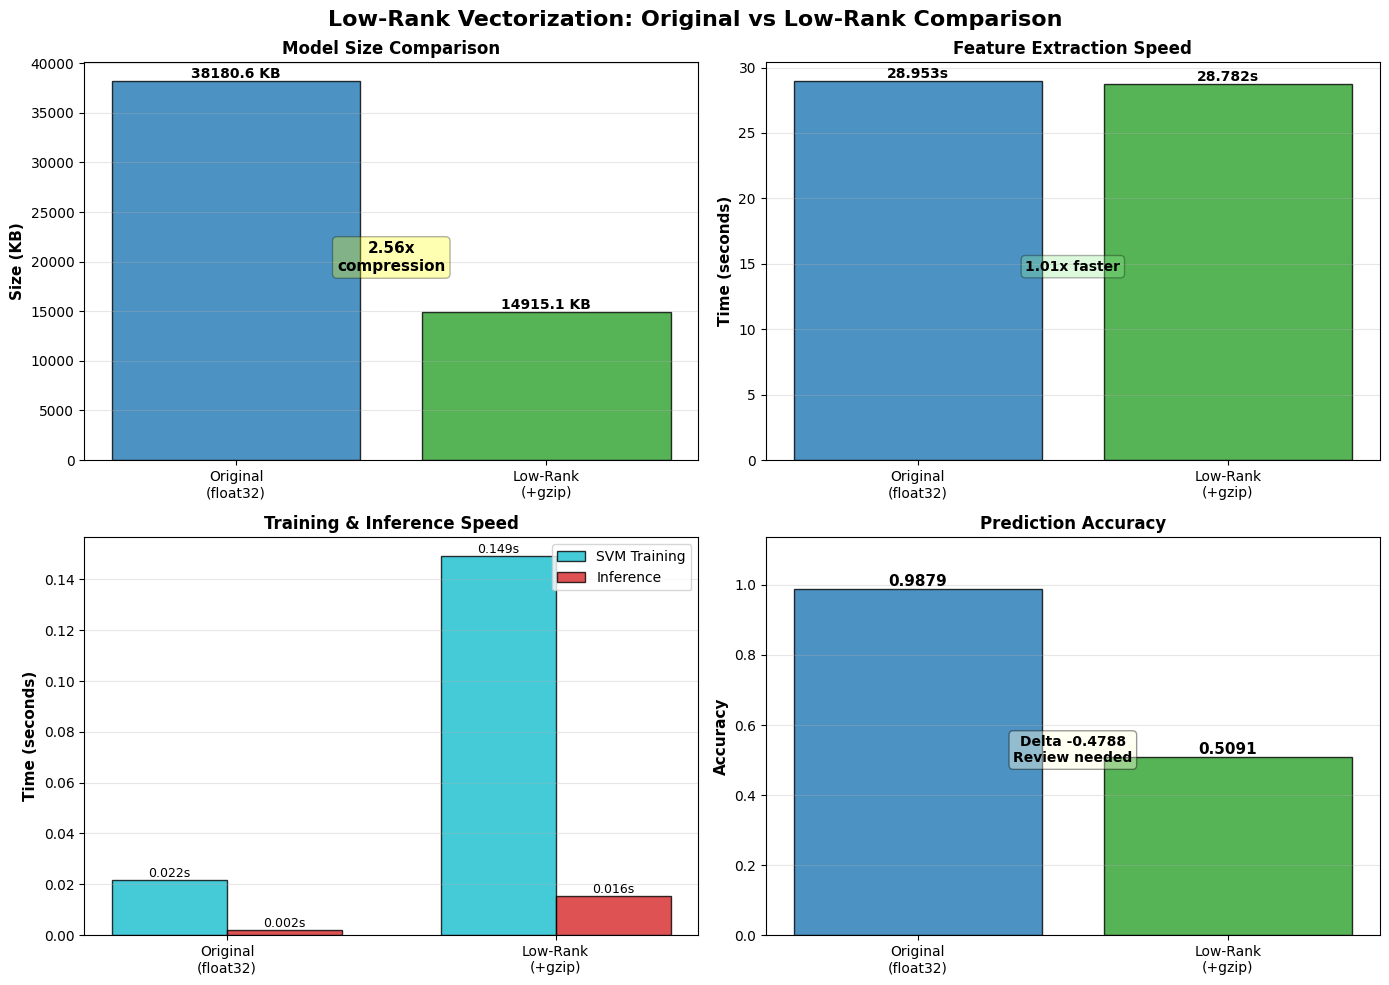


TABEL UKURAN MODEL / ARTEFAK
                  Komponen  Awal (KB)  Setelah Low-Rank (KB)  Setelah Low-Rank + GZIP (KB)
      CNN Attention (main)  38,180.56              38,180.30                     14,915.14
     CNN Feature Extractor  12,754.45              12,754.20                     11,658.81
   SVM (original features)      11.49                  11.49                         11.49
Scaler (original features)       0.98                   0.98                          0.98
   SVM (low-rank features)     131.08                 131.08                        131.08
Scaler (low-rank features)       0.98                   0.98                          0.98
                     TOTAL  51,079.53              51,079.02                     26,718.47

FINAL SUMMARY

Metric                         Original (float32)   Low-Rank (+gzip)    
--------------------------------------------------------------------------------
Model Size (final)                     38180.6 KB            14915.1 KB


In [9]:
"""
Complete CNN + Attention + SVM Pipeline with Low-Rank Vectorization
Trains original float32 model, applies low-rank vectorization, compares both.
"""

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    GlobalAveragePooling2D,
    Reshape,
    Multiply,
    Input,
    Layer,
)
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import os
import time
import gzip
import shutil
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score


# ============================================================================
# PART A: MODEL DEFINITION & TRAINING
# ============================================================================

class ChannelAttention(Layer):
    """Custom Channel Attention Module"""

    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation='relu')
        self.dense2 = Dense(channels, activation='sigmoid')
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


def build_cnn_attention_model(input_shape, num_classes):
    """Build CNN + Attention model"""
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    features = Dense(16, activation='relu', name='feature_layer')(x)
    output = Dense(num_classes, activation='softmax', name='softmax_output')(features)

    return Model(inputs, output, name='CNN_Attention')


# ============================================================================
# PART B: LOW-RANK SETUP & FEATURE EXTRACTION
# ============================================================================

def _gzip_file(src_path, dst_path):
    with open(src_path, 'rb') as f_in, gzip.open(dst_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)


def _file_size_kb(path):
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0


def _compute_target_rank(num_singular_values, rank_ratio):
    rank_ratio = float(np.clip(rank_ratio, 0.05, 1.0))
    target_rank = int(np.ceil(num_singular_values * rank_ratio))
    return max(1, min(num_singular_values, target_rank))


def _low_rank_approx_matrix(matrix_2d, rank_ratio=0.5):
    """Apply truncated SVD to 2D matrix and return approximation + metadata."""
    u, s, vt = np.linalg.svd(matrix_2d, full_matrices=False)
    target_rank = _compute_target_rank(len(s), rank_ratio)

    u_r = u[:, :target_rank]
    s_r = s[:target_rank]
    vt_r = vt[:target_rank, :]

    approx = (u_r * s_r) @ vt_r

    denom = float(np.sum(s ** 2))
    energy_kept = float(np.sum(s_r ** 2) / denom) if denom > 0 else 0.0

    return approx.astype(matrix_2d.dtype), target_rank, energy_kept


def _apply_low_rank_to_weight(weight, rank_ratio=0.5):
    """
    Apply low-rank vectorization to eligible tensors:
    - Dense kernel (2D)
    - Conv kernel (4D) after reshape to 2D
    """
    if weight.ndim == 2:
        approx, rank, energy = _low_rank_approx_matrix(weight, rank_ratio)
        return approx, {'applied': True, 'rank': rank, 'energy_kept': energy, 'shape': tuple(weight.shape)}

    if weight.ndim == 4:
        original_shape = weight.shape
        matrix = weight.reshape(-1, original_shape[-1])
        approx_matrix, rank, energy = _low_rank_approx_matrix(matrix, rank_ratio)
        approx = approx_matrix.reshape(original_shape).astype(weight.dtype)
        return approx, {
            'applied': True,
            'rank': rank,
            'energy_kept': energy,
            'shape': tuple(weight.shape),
            'reshape_2d': tuple(matrix.shape),
        }

    return weight, {'applied': False, 'shape': tuple(weight.shape)}


def build_lowrank_model(base_model, rank_ratio=0.5):
    """Clone model and apply low-rank approximation on trainable kernels."""
    lowrank_model = tf.keras.models.clone_model(base_model)
    lowrank_model.build(base_model.input_shape)
    lowrank_model.set_weights(base_model.get_weights())

    layer_stats = []

    for layer in lowrank_model.layers:
        weights = layer.get_weights()
        if not weights:
            continue

        new_weights = []
        for weight_idx, weight in enumerate(weights):
            transformed, info = _apply_low_rank_to_weight(weight, rank_ratio=rank_ratio)
            info['layer'] = layer.name
            info['weight_idx'] = weight_idx
            layer_stats.append(info)
            new_weights.append(transformed)

        layer.set_weights(new_weights)

    return lowrank_model, layer_stats


def _print_lowrank_stats(layer_stats):
    applied = [s for s in layer_stats if s.get('applied')]
    print(f"[Low-Rank] Eligible tensors transformed: {len(applied)}")

    if not applied:
        print("[Low-Rank] No eligible tensors found. Model unchanged.")
        return

    avg_energy = float(np.mean([s['energy_kept'] for s in applied]))
    avg_rank = float(np.mean([s['rank'] for s in applied]))
    print(f"[Low-Rank] Average retained energy: {avg_energy:.4f}")
    print(f"[Low-Rank] Average target rank: {avg_rank:.2f}")


def setup_lowrank_pipeline(
    model,
    X_train,
    X_valid,
    y_train,
    y_valid,
    batch_size=32,
    lowrank_epochs=5,
    rank_ratio=0.50,
):
    """
    Build size artifacts for 3 stages:
    1) Original format
    2) Low-rank vectorized model
    3) Low-rank vectorized model + compression (gzip)
    """
    os.makedirs('artifacts', exist_ok=True)

    # Build original feature extractor.
    extractor_orig = Model(inputs=model.input, outputs=model.get_layer('feature_layer').output)

    # ---------- Stage 1: original ----------
    cnn_keras_path = 'artifacts/cnn_attention_model.keras'
    ext_keras_path = 'artifacts/cnn_attention_extractor.keras'
    model.save(cnn_keras_path)
    extractor_orig.save(ext_keras_path)
    print(f"[Low-Rank Setup] Original CNN saved -> {cnn_keras_path}")
    print(f"[Low-Rank Setup] Original extractor saved -> {ext_keras_path}")

    # ---------- Stage 2: low-rank vectorization ----------
    print('\n[Low-Rank Setup] Building low-rank model...')
    lowrank_model, layer_stats = build_lowrank_model(model, rank_ratio=rank_ratio)
    _print_lowrank_stats(layer_stats)

    lowrank_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print('[Low-Rank Setup] Fine-tuning low-rank model...')
    t0 = time.time()
    history_lowrank = lowrank_model.fit(
        X_train,
        y_train,
        epochs=lowrank_epochs,
        batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=[EarlyStopping(patience=2, restore_best_weights=True, monitor='val_loss')],
        verbose=1,
    )
    lowrank_finetune_time = time.time() - t0
    print(f"[Low-Rank Setup] Fine-tune time: {lowrank_finetune_time:.3f} s")

    extractor_lowrank = Model(
        inputs=lowrank_model.input,
        outputs=lowrank_model.get_layer('feature_layer').output,
    )

    cnn_lowrank_path = 'artifacts/cnn_attention_lowrank.keras'
    ext_lowrank_path = 'artifacts/cnn_attention_extractor_lowrank.keras'
    lowrank_model.save(cnn_lowrank_path)
    extractor_lowrank.save(ext_lowrank_path)

    print(f"[Low-Rank Setup] Low-rank CNN saved -> {cnn_lowrank_path}")
    print(f"[Low-Rank Setup] Low-rank extractor saved -> {ext_lowrank_path}")

    # ---------- Stage 3: compression (gzip) ----------
    cnn_lowrank_gz_path = 'artifacts/cnn_attention_lowrank.keras.gz'
    ext_lowrank_gz_path = 'artifacts/cnn_attention_extractor_lowrank.keras.gz'
    _gzip_file(cnn_lowrank_path, cnn_lowrank_gz_path)
    _gzip_file(ext_lowrank_path, ext_lowrank_gz_path)

    print(f"[Low-Rank Setup] GZIP low-rank CNN saved -> {cnn_lowrank_gz_path}")
    print(f"[Low-Rank Setup] GZIP low-rank extractor saved -> {ext_lowrank_gz_path}")

    artifact_paths = {
        'cnn_keras': cnn_keras_path,
        'extractor_keras': ext_keras_path,
        'cnn_lowrank': cnn_lowrank_path,
        'extractor_lowrank': ext_lowrank_path,
        'cnn_lowrank_gz': cnn_lowrank_gz_path,
        'extractor_lowrank_gz': ext_lowrank_gz_path,
    }

    return (
        artifact_paths,
        lowrank_model,
        extractor_lowrank,
        history_lowrank,
        lowrank_finetune_time,
        layer_stats,
    )


def extract_features_keras(extractor_model, X):
    """Extract features using Keras feature extractor."""
    return extractor_model.predict(X, verbose=0)


def build_size_table(artifact_paths, svm_orig_path, scaler_orig_path, svm_lowrank_path, scaler_lowrank_path):
    """Build size table for initial, low-rank, and compressed stages."""
    rows = [
        {
            'Komponen': 'CNN Attention (main)',
            'Awal (KB)': _file_size_kb(artifact_paths['cnn_keras']),
            'Setelah Low-Rank (KB)': _file_size_kb(artifact_paths['cnn_lowrank']),
            'Setelah Low-Rank + GZIP (KB)': _file_size_kb(artifact_paths['cnn_lowrank_gz']),
        },
        {
            'Komponen': 'CNN Feature Extractor',
            'Awal (KB)': _file_size_kb(artifact_paths['extractor_keras']),
            'Setelah Low-Rank (KB)': _file_size_kb(artifact_paths['extractor_lowrank']),
            'Setelah Low-Rank + GZIP (KB)': _file_size_kb(artifact_paths['extractor_lowrank_gz']),
        },
        {
            'Komponen': 'SVM (original features)',
            'Awal (KB)': _file_size_kb(svm_orig_path),
            'Setelah Low-Rank (KB)': _file_size_kb(svm_orig_path),
            'Setelah Low-Rank + GZIP (KB)': _file_size_kb(svm_orig_path),
        },
        {
            'Komponen': 'Scaler (original features)',
            'Awal (KB)': _file_size_kb(scaler_orig_path),
            'Setelah Low-Rank (KB)': _file_size_kb(scaler_orig_path),
            'Setelah Low-Rank + GZIP (KB)': _file_size_kb(scaler_orig_path),
        },
        {
            'Komponen': 'SVM (low-rank features)',
            'Awal (KB)': _file_size_kb(svm_lowrank_path),
            'Setelah Low-Rank (KB)': _file_size_kb(svm_lowrank_path),
            'Setelah Low-Rank + GZIP (KB)': _file_size_kb(svm_lowrank_path),
        },
        {
            'Komponen': 'Scaler (low-rank features)',
            'Awal (KB)': _file_size_kb(scaler_lowrank_path),
            'Setelah Low-Rank (KB)': _file_size_kb(scaler_lowrank_path),
            'Setelah Low-Rank + GZIP (KB)': _file_size_kb(scaler_lowrank_path),
        },
    ]

    df = pd.DataFrame(rows)

    total_row = {
        'Komponen': 'TOTAL',
        'Awal (KB)': df['Awal (KB)'].sum(),
        'Setelah Low-Rank (KB)': df['Setelah Low-Rank (KB)'].sum(),
        'Setelah Low-Rank + GZIP (KB)': df['Setelah Low-Rank + GZIP (KB)'].sum(),
    }

    df = pd.concat([df, pd.DataFrame([total_row])], ignore_index=True)
    return df


def print_size_table(size_df):
    print('\n' + '=' * 105)
    print('TABEL UKURAN MODEL / ARTEFAK')
    print('=' * 105)
    with pd.option_context('display.max_colwidth', None, 'display.float_format', '{:,.2f}'.format):
        print(size_df.to_string(index=False))
    print('=' * 105)


# ============================================================================
# PART C: PIPELINE EXECUTION & COMPARISON
# ============================================================================

def run_complete_pipeline(model, X_train, X_valid, X_test, y_train, y_valid, y_test):
    """
    Execute complete pipeline:
    1. Use trained original model
    2. Apply low-rank vectorization + fine-tuning
    3. Run feature extraction on both pipelines
    4. Train SVM on both
    5. Compare results + artifact size table
    """

    # Convert labels to integers
    y_train_int = np.argmax(y_train, axis=1)
    y_valid_int = np.argmax(y_valid, axis=1)
    y_test_int = np.argmax(y_test, axis=1)

    # Setup low-rank + artifact paths
    (
        artifact_paths,
        lowrank_model,
        extractor_lowrank,
        history_lowrank,
        lowrank_finetune_time,
        lowrank_stats,
    ) = setup_lowrank_pipeline(model, X_train, X_valid, y_train, y_valid)

    # ---------------------------------------------------------------------
    print('\n' + '=' * 70)
    print('PIPELINE A: ORIGINAL MODEL (float32)')
    print('=' * 70)

    size_orig_kb = _file_size_kb(artifact_paths['cnn_keras'])
    print(f"Model size: {size_orig_kb:.1f} KB")

    # Feature extraction
    extractor_orig = Model(inputs=model.input, outputs=model.get_layer('feature_layer').output)

    t0 = time.time()
    X_train_feat_orig = extract_features_keras(extractor_orig, X_train)
    X_val_feat_orig = extract_features_keras(extractor_orig, X_valid)
    X_test_feat_orig = extract_features_keras(extractor_orig, X_test)
    t_feat_orig = time.time() - t0

    print(f"Feature extraction time: {t_feat_orig:.3f} s")
    print(f"Feature shape: {X_test_feat_orig.shape}")

    # Normalize
    scaler_orig = StandardScaler()
    X_train_scaled_orig = scaler_orig.fit_transform(X_train_feat_orig)
    X_val_scaled_orig = scaler_orig.transform(X_val_feat_orig)
    X_test_scaled_orig = scaler_orig.transform(X_test_feat_orig)

    # Combine train+val
    X_svm_train_orig = np.vstack([X_train_scaled_orig, X_val_scaled_orig])
    y_svm_train_orig = np.concatenate([y_train_int, y_valid_int])

    # Train SVM
    t0 = time.time()
    svm_orig = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    svm_orig.fit(X_svm_train_orig, y_svm_train_orig)
    t_svm_orig = time.time() - t0

    print(f"SVM training time: {t_svm_orig:.3f} s")

    # Inference
    t0 = time.time()
    y_pred_orig = svm_orig.predict(X_test_scaled_orig)
    y_proba_orig = svm_orig.predict_proba(X_test_scaled_orig)
    t_inf_orig = time.time() - t0

    acc_orig = accuracy_score(y_test_int, y_pred_orig)
    print(f"Inference time: {t_inf_orig:.4f} s")
    print(f"Test accuracy: {acc_orig:.4f}")
    print('\nClassification Report (Original):')
    print(classification_report(y_test_int, y_pred_orig, zero_division=0))

    # ---------------------------------------------------------------------
    print('\n' + '=' * 70)
    print('PIPELINE B: LOW-RANK MODEL')
    print('=' * 70)

    size_lowrank_kb = _file_size_kb(artifact_paths['cnn_lowrank'])
    size_lowrank_gz_kb = _file_size_kb(artifact_paths['cnn_lowrank_gz'])
    compression_gz = size_orig_kb / size_lowrank_gz_kb if size_lowrank_gz_kb > 0 else 0.0
    print(f"Model size (low-rank .keras): {size_lowrank_kb:.1f} KB")
    print(f"Model size (low-rank .keras.gz): {size_lowrank_gz_kb:.1f} KB")
    print(f"Compression vs original (gzip): {compression_gz:.2f}x")

    # Feature extraction
    t0 = time.time()
    X_train_feat_lowrank = extract_features_keras(extractor_lowrank, X_train)
    X_val_feat_lowrank = extract_features_keras(extractor_lowrank, X_valid)
    X_test_feat_lowrank = extract_features_keras(extractor_lowrank, X_test)
    t_feat_lowrank = time.time() - t0

    print(f"Feature extraction time: {t_feat_lowrank:.3f} s")
    print(f"Feature shape: {X_test_feat_lowrank.shape}")

    # Normalize
    scaler_lowrank = StandardScaler()
    X_train_scaled_lowrank = scaler_lowrank.fit_transform(X_train_feat_lowrank)
    X_val_scaled_lowrank = scaler_lowrank.transform(X_val_feat_lowrank)
    X_test_scaled_lowrank = scaler_lowrank.transform(X_test_feat_lowrank)

    # Combine train+val
    X_svm_train_lowrank = np.vstack([X_train_scaled_lowrank, X_val_scaled_lowrank])
    y_svm_train_lowrank = np.concatenate([y_train_int, y_valid_int])

    # Train SVM
    t0 = time.time()
    svm_lowrank = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    svm_lowrank.fit(X_svm_train_lowrank, y_svm_train_lowrank)
    t_svm_lowrank = time.time() - t0

    print(f"SVM training time: {t_svm_lowrank:.3f} s")

    # Inference
    t0 = time.time()
    y_pred_lowrank = svm_lowrank.predict(X_test_scaled_lowrank)
    y_proba_lowrank = svm_lowrank.predict_proba(X_test_scaled_lowrank)
    t_inf_lowrank = time.time() - t0

    acc_lowrank = accuracy_score(y_test_int, y_pred_lowrank)
    print(f"Inference time: {t_inf_lowrank:.4f} s")
    print(f"Test accuracy: {acc_lowrank:.4f}")
    print('\nClassification Report (Low-Rank):')
    print(classification_report(y_test_int, y_pred_lowrank, zero_division=0))

    # Save sklearn artifacts for size reporting.
    os.makedirs('artifacts', exist_ok=True)
    svm_orig_path = 'artifacts/svm_original.pkl'
    scaler_orig_path = 'artifacts/scaler_original.pkl'
    svm_lowrank_path = 'artifacts/svm_lowrank.pkl'
    scaler_lowrank_path = 'artifacts/scaler_lowrank.pkl'

    joblib.dump(svm_orig, svm_orig_path)
    joblib.dump(scaler_orig, scaler_orig_path)
    joblib.dump(svm_lowrank, svm_lowrank_path)
    joblib.dump(scaler_lowrank, scaler_lowrank_path)

    size_df = build_size_table(
        artifact_paths,
        svm_orig_path,
        scaler_orig_path,
        svm_lowrank_path,
        scaler_lowrank_path,
    )

    # ---------------------------------------------------------------------
    # Collect metrics
    metrics = {
        'size_kb': [size_orig_kb, size_lowrank_gz_kb],
        'size_lowrank_raw_kb': [size_orig_kb, size_lowrank_kb],
        't_feature': [t_feat_orig, t_feat_lowrank],
        't_svm': [t_svm_orig, t_svm_lowrank],
        't_infer': [t_inf_orig, t_inf_lowrank],
        'accuracy': [acc_orig, acc_lowrank],
        'lowrank_finetune_time': lowrank_finetune_time,
        'lowrank_transformed_tensors': int(len([s for s in lowrank_stats if s.get('applied')])),
    }

    eval_data = (y_test_int, y_pred_orig, y_pred_lowrank, y_proba_orig, y_proba_lowrank)

    # Save important variables to notebook globals for follow-up evaluation cells.
    globals()['y_test_int'] = y_test_int
    globals()['y_pred_orig'] = y_pred_orig
    globals()['y_pred_lowrank'] = y_pred_lowrank
    globals()['y_proba_orig'] = y_proba_orig
    globals()['y_proba_lowrank'] = y_proba_lowrank

    # Backward compatibility with old PTQ/pruning variable names in later cells.
    globals()['y_pred_ptq'] = y_pred_lowrank
    globals()['y_proba_ptq'] = y_proba_lowrank
    globals()['y_pred_pruned'] = y_pred_lowrank
    globals()['y_proba_pruned'] = y_proba_lowrank

    globals()['t_svm_orig'] = t_svm_orig
    globals()['t_svm_ptq'] = t_svm_lowrank
    globals()['t_svm_lowrank'] = t_svm_lowrank

    return metrics, eval_data, size_df, history_lowrank


# ============================================================================
# PART D: VISUALIZATION & SUMMARY
# ============================================================================

def visualize_comparison(metrics):
    """Create 4-panel matplotlib comparison dashboard."""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Low-Rank Vectorization: Original vs Low-Rank Comparison', fontsize=16, fontweight='bold')

    models = ['Original\n(float32)', 'Low-Rank\n(+gzip)']
    colors = ['#1f77b4', '#2ca02c']

    # ---------------------------------------------------------------------
    # Plot 1: Model Size
    # ---------------------------------------------------------------------
    ax = axes[0, 0]
    bars = ax.bar(models, metrics['size_kb'], color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Size (KB)', fontsize=11, fontweight='bold')
    ax.set_title('Model Size Comparison', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, metrics['size_kb']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, height, f'{val:.1f} KB', ha='center', va='bottom', fontweight='bold', fontsize=10)

    compression = metrics['size_kb'][0] / metrics['size_kb'][1] if metrics['size_kb'][1] > 0 else 0.0
    ax.text(
        0.5,
        max(metrics['size_kb']) * 0.5,
        f'{compression:.2f}x\ncompression',
        ha='center',
        fontsize=11,
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3),
    )

    # ---------------------------------------------------------------------
    # Plot 2: Feature Extraction Time
    # ---------------------------------------------------------------------
    ax = axes[0, 1]
    bars = ax.bar(models, metrics['t_feature'], color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title('Feature Extraction Speed', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, metrics['t_feature']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, height, f'{val:.3f}s', ha='center', va='bottom', fontweight='bold', fontsize=10)

    speedup = metrics['t_feature'][0] / metrics['t_feature'][1] if metrics['t_feature'][1] > 0 else 0.0
    speedup_text = f'{speedup:.2f}x faster' if speedup >= 1 else f'{1 / speedup:.2f}x slower'
    ax.text(
        0.5,
        max(metrics['t_feature']) * 0.5,
        speedup_text,
        ha='center',
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            boxstyle='round',
            facecolor='lightgreen' if speedup >= 1 else 'lightcoral',
            alpha=0.3,
        ),
    )

    # ---------------------------------------------------------------------
    # Plot 3: Training & Inference Time
    # ---------------------------------------------------------------------
    ax = axes[1, 0]
    x = np.arange(len(models))
    width = 0.35

    bars1 = ax.bar(x - width / 2, metrics['t_svm'], width, label='SVM Training', color='#17becf', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width / 2, metrics['t_infer'], width, label='Inference', color='#d62728', alpha=0.8, edgecolor='black')

    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title('Training & Inference Speed', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.3f}s', ha='center', va='bottom', fontsize=9)

    # ---------------------------------------------------------------------
    # Plot 4: Accuracy
    # ---------------------------------------------------------------------
    ax = axes[1, 1]
    bars = ax.bar(models, metrics['accuracy'], color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Prediction Accuracy', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(metrics['accuracy']) * 1.15)

    for bar, val in zip(bars, metrics['accuracy']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, height, f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

    delta_acc = metrics['accuracy'][1] - metrics['accuracy'][0]
    status = 'Acceptable' if abs(delta_acc) < 0.02 else 'Review needed'
    ax.text(
        0.5,
        max(metrics['accuracy']) * 0.5,
        f'Delta {delta_acc:+.4f}\n{status}',
        ha='center',
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            boxstyle='round',
            facecolor='lightgreen' if abs(delta_acc) < 0.02 else 'lightyellow',
            alpha=0.4,
        ),
    )

    plt.tight_layout()
    plt.savefig('lowrank_comparison.png', dpi=150, bbox_inches='tight')
    print('\nVisualization saved: lowrank_comparison.png')
    plt.show()


def print_summary(metrics, eval_data, size_df):
    """Print detailed summary table + artifact size table."""

    print_size_table(size_df)

    print('\n' + '=' * 80)
    print('FINAL SUMMARY')
    print('=' * 80)
    print(f"\n{'Metric':<30} {'Original (float32)':<20} {'Low-Rank (+gzip)':<20}")
    print('-' * 80)
    print(f"{'Model Size (final)':<30} {metrics['size_kb'][0]:>15.1f} KB    {metrics['size_kb'][1]:>15.1f} KB")
    print(f"{'Model Size (raw low-rank)':<30} {metrics['size_lowrank_raw_kb'][0]:>15.1f} KB    {metrics['size_lowrank_raw_kb'][1]:>15.1f} KB")
    print(f"{'Compression (final)':<30} {'1.0x':<20} {metrics['size_kb'][0] / metrics['size_kb'][1]:>15.2f}x")
    print(f"{'Feature Extraction':<30} {metrics['t_feature'][0]:>15.3f} s    {metrics['t_feature'][1]:>15.3f} s")
    print(f"{'SVM Training':<30} {metrics['t_svm'][0]:>15.3f} s    {metrics['t_svm'][1]:>15.3f} s")
    print(f"{'Inference':<30} {metrics['t_infer'][0]:>15.4f} s    {metrics['t_infer'][1]:>15.4f} s")
    print(f"{'Low-Rank Fine-tune':<30} {'-':<20} {metrics['lowrank_finetune_time']:>15.3f} s")
    print(f"{'Accuracy':<30} {metrics['accuracy'][0]:>15.4f}    {metrics['accuracy'][1]:>15.4f}")
    print(f"{'Delta Accuracy':<30} {'-':<20} {metrics['accuracy'][1] - metrics['accuracy'][0]:>+15.4f}")
    print(f"{'Transformed Tensors':<30} {'-':<20} {metrics['lowrank_transformed_tensors']:>15d}")
    print('=' * 80)

    print('\nKey Findings:')
    compression = metrics['size_kb'][0] / metrics['size_kb'][1] if metrics['size_kb'][1] > 0 else 0.0
    print(f"  - Final size reduced by {compression:.2f}x ({metrics['size_kb'][0]:.1f} KB -> {metrics['size_kb'][1]:.1f} KB)")

    speedup_feat = metrics['t_feature'][0] / metrics['t_feature'][1] if metrics['t_feature'][1] > 0 else 0.0
    feat_status = 'faster' if speedup_feat >= 1 else 'slower'
    print(f"  - Feature extraction {feat_status} ({speedup_feat:.2f}x)")

    delta_acc = metrics['accuracy'][1] - metrics['accuracy'][0]
    if abs(delta_acc) < 0.001:
        acc_status = 'Negligible change'
    elif abs(delta_acc) < 0.02:
        acc_status = 'Within acceptable tolerance'
    else:
        acc_status = 'Significant drop, consider higher rank_ratio'
    print(f"  - Accuracy impact: {delta_acc:+.4f} ({acc_status})")


# ============================================================================
# MAIN SCRIPT
# ============================================================================

if __name__ == '__main__':
    """
    INSTRUCTIONS:
    1. Load your data first:
       from your_data_module import X_train, X_valid, X_test, y_train, y_valid, y_test

    2. Run this script:
       python cnn_attention_lowrank_complete.py

    The script will:
    - Build CNN + Attention model
    - Train the model
    - Apply low-rank vectorization + fine-tuning
    - Compare performance: original vs low-rank
    - Generate matplotlib visualization
    - Print detailed summary + size table
    """

    try:
        # Get number of classes
        num_classes = y_train.shape[1]

        # Build model
        print('=' * 70)
        print('Building CNN + Attention Model')
        print('=' * 70)
        model = build_cnn_attention_model(X_train.shape[1:], num_classes)
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        model.summary()

        # Train base model
        print('\n' + '=' * 70)
        print('Training Base Model')
        print('=' * 70)
        t0 = time.time()
        history = model.fit(
            X_train,
            y_train,
            epochs=30,
            batch_size=32,
            validation_data=(X_valid, y_valid),
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')],
            verbose=1,
        )
        training_time_cnn = time.time() - t0
        fit_time_sec = training_time_cnn
        print(f"CNN training time: {training_time_cnn:.4f} s")

        # Run complete pipeline (original + low-rank comparison)
        print('\n' + '=' * 70)
        print('Running Low-Rank Vectorization & Comparison Pipeline')
        print('=' * 70)
        metrics, eval_data, size_df, history_lowrank = run_complete_pipeline(
            model,
            X_train,
            X_valid,
            X_test,
            y_train,
            y_valid,
            y_test,
        )

        # Visualize
        print('\n' + '=' * 70)
        print('Generating Comparison Visualizations')
        print('=' * 70)
        visualize_comparison(metrics)

        # Print summary + table
        print_summary(metrics, eval_data, size_df)

    except NameError as e:
        print(f"Error: {e}")
        print('\nPlease ensure the following are loaded in your scope:')
        print('  - X_train, X_valid, X_test (numpy arrays)')
        print('  - y_train, y_valid, y_test (one-hot encoded labels)')
        print('\nExample:')
        print('  from your_data_module import X_train, X_valid, X_test, y_train, y_valid, y_test')
        print("  exec(open('cnn_attention_lowrank_complete.py').read())")